<a href="https://colab.research.google.com/github/estebanszd/Clase-Introducci-n-/blob/main/QA_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 QA Dataset Analysis — Medical Interpretation Team
**Assessment: Data Analysis Proficiency (20%)**  
**Dataset:** 78 audited calls | 12 agents | 4-week review period  
**Performance threshold:** 90% QA Score  

---
### Table of Contents
1. [Setup & Data Load](#1-setup)
2. [Dataset Overview & Quality Check](#2-overview)
3. [Task 1–3: Average QA Score per Agent + Critical Errors + Below-90% Flag](#3-agent-summary)
4. [Task 4: Error Type Distribution (Pivot Table)](#4-error-pivot)
5. [Task 5: Error Severity Analysis](#5-severity)
6. [Task 6: Top 3 Error Types — Bar Chart](#6-chart)
7. [Task 7: Conditional Formatting Logic (Color-coded QA Scores)](#7-cf)
8. [Task 8: Written Interpretation of Results](#8-interpretation)
9. [Bonus: Additional Deep-Dive Analyses](#9-bonus)

## 1. Setup & Data Load <a id='1-setup'></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
sns.set_palette('Blues_d')

THRESHOLD = 0.90          # QA pass/fail line
RED   = '#d62728'
AMBER = '#ff7f0e'
GREEN = '#2ca02c'
BLUE  = '#1f77b4'
NAVY  = '#1F4E79'

df = pd.read_excel(
    "/content/QA Job Opening - Assessment.xlsx",
    sheet_name='Dataset',
    parse_dates=['Audit Date']
)

# Clean up
df.columns = df.columns.str.strip()
df['QA Score'] = df['QA Score'].astype(float)
df['Critical Error'] = df['Critical Error'].str.strip()
df['Missing Call']   = df['Missing Call'].str.strip()
df['Error Type']     = df['Error Type'].str.strip()
df['Error Severity'] = df['Error Severity'].str.strip()

print(f'Rows: {len(df)} | Columns: {df.shape[1]}')
df.head()

Rows: 78 | Columns: 17


,Audit ID,Agent Alias,Supervisor Alias,Tenure Bucket,Audit Date,Week,QA Score,Critical Error,Error Type,Error Severity,Call Type,Language Pair,Auditor Alias,Ring Time Sec,Missing Call,Call Length Min,QA Observation
0,QA-1001,Agent A,Supervisor Alpha,90+ days,2026-05-04,Week 1,0.94,No,No Error,NaN,Mental Health,Spanish <> English,QA Analyst 1,6,No,6.2,No material error observed in audited segment.
1,QA-1002,Agent A,Supervisor Alpha,90+ days,2026-05-05,Week 1,0.95,No,Terminology,Major,Lab Results,Haitian Creole <> English,QA Analyst 1,12,No,13.3,Medical term was interpreted incorrectly or in...
2,QA-1003,Agent B,Supervisor Beta,31-60 days,2026-05-05,Week 1,0.72,Yes,Accuracy,Critical,Pharmacy,Spanish <> English,QA Analyst 1,10,No,6.4,Meaning was changed or key clinical detail was...
3,QA-1004,Agent B,Supervisor Beta,31-60 days,2026-05-07,Week 1,0.71,No,Omission,Major,Pharmacy,Spanish <> English,QA Analyst 3,11,No,16.6,Relevant information from speaker was not full...
4,QA-1005,Agent C,Supervisor Gamma,61-90 days,2026-05-05,Week 1,0.90,No,Terminology,Minor,Pharmacy,Spanish <> English,QA Analyst 2,4,No,16.9,Medical term was interpreted incorrectly or in...


## 2. Dataset Overview & Quality Check <a id='2-overview'></a>

In [5]:
print('─' * 45)
print('COLUMN TYPES & NULL COUNT')
print('─' * 45)
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isnull().sum(),
    'unique': df.nunique()
})
display(info)

print('\nQA SCORE DESCRIPTIVE STATS')
display(df[['QA Score', 'Ring Time Sec', 'Call Length Min']].describe().round(3))

─────────────────────────────────────────────
COLUMN TYPES & NULL COUNT
─────────────────────────────────────────────


,dtype,nulls,unique
Audit ID,object,0,78
Agent Alias,object,0,12
Supervisor Alias,object,0,3
Tenure Bucket,object,0,4
Audit Date,datetime64[ns],0,20
Week,object,0,4
QA Score,float64,0,27
Critical Error,object,0,2
Error Type,object,0,9
Error Severity,object,19,3



QA SCORE DESCRIPTIVE STATS


,QA Score,Ring Time Sec,Call Length Min
count,78.000,78.000,78.000
mean,0.863,11.359,13.367
std,0.085,3.971,5.292
min,0.680,4.000,4.500
25%,0.792,9.000,9.150
50%,0.875,11.000,13.200
75%,0.930,14.000,17.550
max,1.000,22.000,23.900


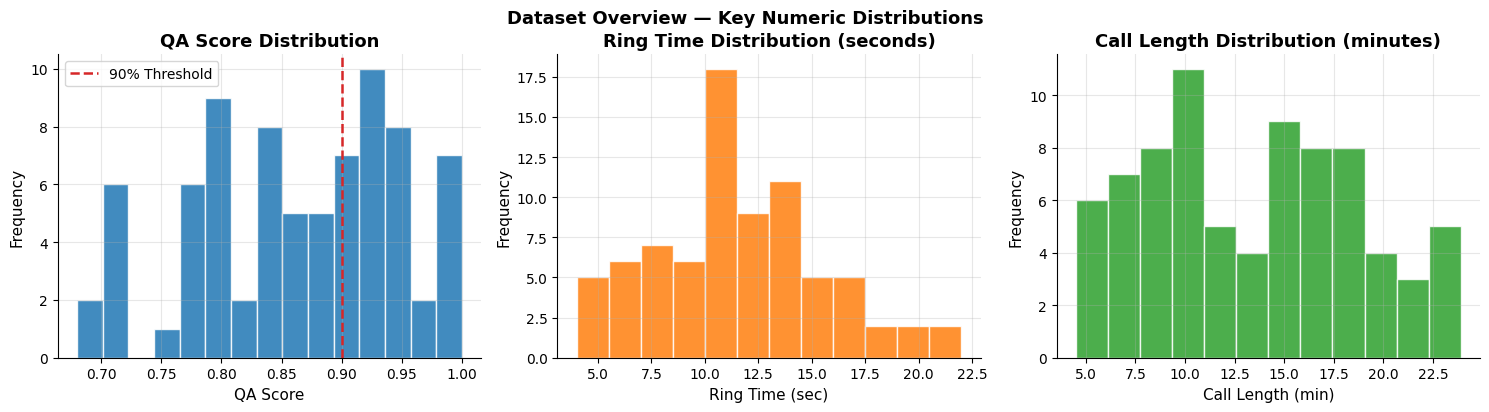

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# QA Score histogram
axes[0].hist(df['QA Score'], bins=15, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(THRESHOLD, color=RED, linestyle='--', linewidth=1.8, label='90% Threshold')
axes[0].set_title('QA Score Distribution')
axes[0].set_xlabel('QA Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Ring Time histogram
axes[1].hist(df['Ring Time Sec'], bins=12, color=AMBER, edgecolor='white', alpha=0.85)
axes[1].set_title('Ring Time Distribution (seconds)')
axes[1].set_xlabel('Ring Time (sec)')
axes[1].set_ylabel('Frequency')

# Call Length histogram
axes[2].hist(df['Call Length Min'], bins=12, color=GREEN, edgecolor='white', alpha=0.85)
axes[2].set_title('Call Length Distribution (minutes)')
axes[2].set_xlabel('Call Length (min)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.suptitle('Dataset Overview — Key Numeric Distributions', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 3. Tasks 1–3: Average QA Score per Agent | Critical Errors | Below-90% Flag <a id='3-agent-summary'></a>

In [7]:
# ── Equivalent Excel formulas used per agent ────────────────────────────────
# AVERAGEIF(Agent col, agent_name, QA Score col)  → Avg QA
# COUNTIF(Agent col, agent_name)                  → Audits
# COUNTIFS(Agent col, name, Critical Error col, 'Yes') → Critical Errors
# IF(avg_qa < 0.9, 'Yes', 'No')                   → Below 90% flag
# MINIFS / MAXIFS(QA Score, Agent, name)          → Min / Max QA

summary = (
    df.groupby('Agent Alias')
    .agg(
        Audits        = ('Audit ID',       'count'),
        Avg_QA        = ('QA Score',        'mean'),
        Min_QA        = ('QA Score',        'min'),
        Max_QA        = ('QA Score',        'max'),
        Critical_Errs = ('Critical Error',  lambda x: (x == 'Yes').sum()),
        Missing_Calls = ('Missing Call',    lambda x: (x == 'Yes').sum()),
        Avg_Ring_Time = ('Ring Time Sec',   'mean'),
    )
    .reset_index()
)

summary['Below_90%'] = summary['Avg_QA'].apply(lambda s: 'Yes' if s < 0.90 else 'No')
summary['Status'] = summary['Avg_QA'].apply(
    lambda s: '🔴 CRITICAL' if s < 0.80 else ('🟡 AT RISK' if s < 0.90 else '🟢 PASSING')
)
summary = summary.sort_values('Avg_QA')

# Format for display
disp = summary.copy()
for col in ['Avg_QA','Min_QA','Max_QA']:
    disp[col] = disp[col].map('{:.1%}'.format)
disp['Avg_Ring_Time'] = disp['Avg_Ring_Time'].map('{:.1f} sec'.format)
display(disp)

below = (summary['Below_90%'] == 'Yes').sum()
print(f'\n► {below} of {len(summary)} agents ({below/len(summary):.0%}) are BELOW the 90% threshold.')
print(f'► Team average QA: {summary["Avg_QA"].mean():.1%}')

,Agent Alias,Audits,Avg_QA,Min_QA,Max_QA,Critical_Errs,Missing_Calls,Avg_Ring_Time,Below_90%,Status
1,Agent B,7,74.1%,68.0%,81.0%,4,0,12.9 sec,Yes,🔴 CRITICAL
3,Agent D,6,74.7%,68.0%,80.0%,4,1,16.7 sec,Yes,🔴 CRITICAL
9,Agent J,7,78.9%,72.0%,85.0%,2,1,16.0 sec,Yes,🔴 CRITICAL
2,Agent C,6,84.0%,78.0%,90.0%,1,0,9.7 sec,Yes,🟡 AT RISK
5,Agent F,7,85.6%,77.0%,94.0%,0,0,10.7 sec,Yes,🟡 AT RISK
11,Agent L,6,87.3%,83.0%,92.0%,0,0,12.8 sec,Yes,🟡 AT RISK
4,Agent E,4,89.5%,86.0%,94.0%,0,1,7.2 sec,Yes,🟡 AT RISK
10,Agent K,7,90.1%,83.0%,96.0%,0,0,10.9 sec,No,🟢 PASSING
6,Agent G,7,90.7%,80.0%,100.0%,0,0,9.1 sec,No,🟢 PASSING
7,Agent H,7,90.9%,80.0%,100.0%,0,1,12.6 sec,No,🟢 PASSING



► 7 of 12 agents (58%) are BELOW the 90% threshold.
► Team average QA: 86.3%


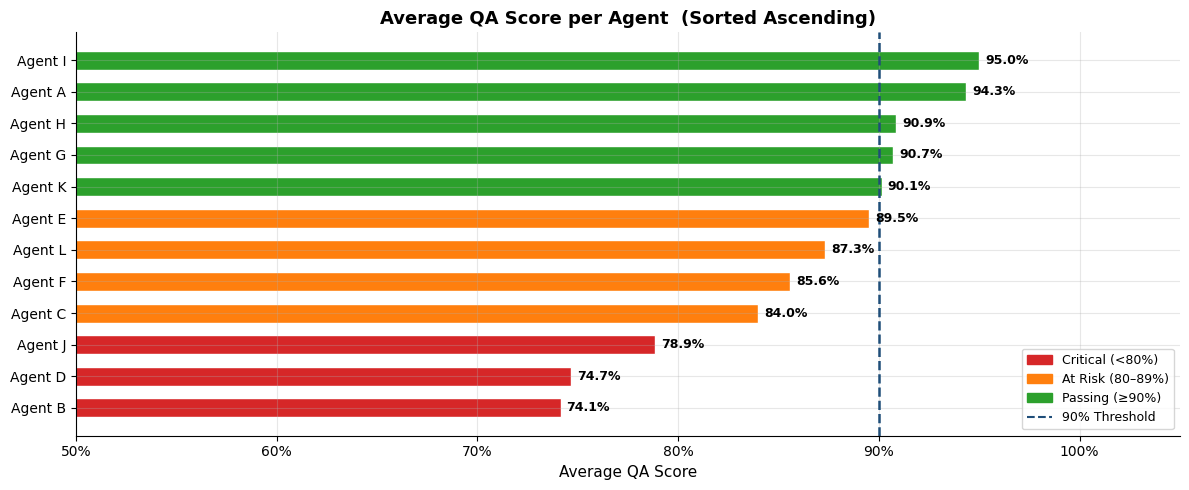

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = [RED if s < 0.80 else (AMBER if s < 0.90 else GREEN) for s in summary['Avg_QA']]
bars = ax.barh(summary['Agent Alias'], summary['Avg_QA'], color=colors, edgecolor='white', height=0.6)

ax.axvline(THRESHOLD, color=NAVY, linestyle='--', linewidth=1.8, label='90% Threshold')
ax.set_xlim(0.5, 1.05)
ax.set_xlabel('Average QA Score')
ax.set_title('Average QA Score per Agent  (Sorted Ascending)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

for bar, val in zip(bars, summary['Avg_QA']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9, fontweight='bold')

patches = [
    mpatches.Patch(color=RED,   label='Critical (<80%)'),
    mpatches.Patch(color=AMBER, label='At Risk (80–89%)'),
    mpatches.Patch(color=GREEN, label='Passing (≥90%)'),
]
ax.legend(handles=patches + [plt.Line2D([0],[0], color=NAVY, linestyle='--', label='90% Threshold')],
          loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

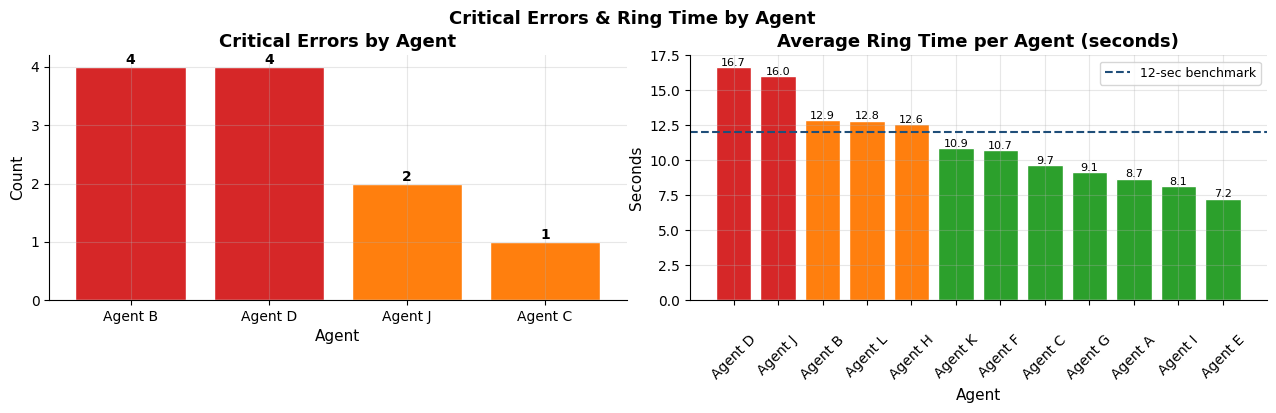

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Critical errors per agent
crit = summary[summary['Critical_Errs'] > 0].sort_values('Critical_Errs', ascending=False)
axes[0].bar(crit['Agent Alias'], crit['Critical_Errs'],
            color=[RED if v > 2 else AMBER for v in crit['Critical_Errs']], edgecolor='white')
axes[0].set_title('Critical Errors by Agent')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Agent')
for i, (ag, v) in enumerate(zip(crit['Agent Alias'], crit['Critical_Errs'])):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

# Ring time per agent
ring = summary.sort_values('Avg_Ring_Time', ascending=False)
ring_colors = [RED if v > 15 else (AMBER if v > 11 else GREEN) for v in ring['Avg_Ring_Time']]
axes[1].bar(ring['Agent Alias'], ring['Avg_Ring_Time'], color=ring_colors, edgecolor='white')
axes[1].axhline(12, color=NAVY, linestyle='--', linewidth=1.5, label='12-sec benchmark')
axes[1].set_title('Average Ring Time per Agent (seconds)')
axes[1].set_ylabel('Seconds')
axes[1].set_xlabel('Agent')
axes[1].tick_params(axis='x', pad=20, rotation=45) # Increased padding to 20 and added rotation
axes[1].legend(fontsize=9)
for i, (ag, v) in enumerate(zip(ring['Agent Alias'], ring['Avg_Ring_Time'])):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.suptitle('Critical Errors & Ring Time by Agent', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 4. Task 4: Error Type Distribution — Pivot Table <a id='4-error-pivot'></a>

In [10]:
# Pivot: Agent × Error Type  (equivalent to Excel PivotTable)
pivot = (
    df.groupby(['Agent Alias', 'Error Type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
pivot.set_index('Agent Alias', inplace=True)
pivot['TOTAL ERRORS'] = pivot.drop(columns=['No Error'], errors='ignore').sum(axis=1)

# Move TOTAL to end
cols = [c for c in pivot.columns if c not in ['No Error','TOTAL ERRORS']] + ['No Error','TOTAL ERRORS']
pivot = pivot[cols]

display(pivot)

print('\n── Column Totals ──')
totals = pivot.sum().to_frame('Total').T
display(totals)

Error Type,Accuracy,Addition,Background Noise,Confidentiality,Omission,Professionalism,Protocol,Terminology,No Error,TOTAL ERRORS
Agent Alias,,,,,,,,,,
Agent A,0,0,0,0,0,0,2,1,3,3
Agent B,1,0,0,0,1,0,0,5,0,7
Agent C,0,0,2,0,0,0,0,4,0,6
Agent D,0,0,0,0,4,0,2,0,0,6
Agent E,0,2,0,0,0,0,0,1,1,3
Agent F,2,0,0,0,0,2,0,1,2,5
Agent G,0,0,0,0,0,0,0,2,5,2
Agent H,2,0,3,0,0,0,1,0,1,6
Agent I,0,1,0,0,0,0,2,0,5,3



── Column Totals ──


Error Type,Accuracy,Addition,Background Noise,Confidentiality,Omission,Professionalism,Protocol,Terminology,No Error,TOTAL ERRORS
Total,8,3,7,3,7,4,9,18,19,59


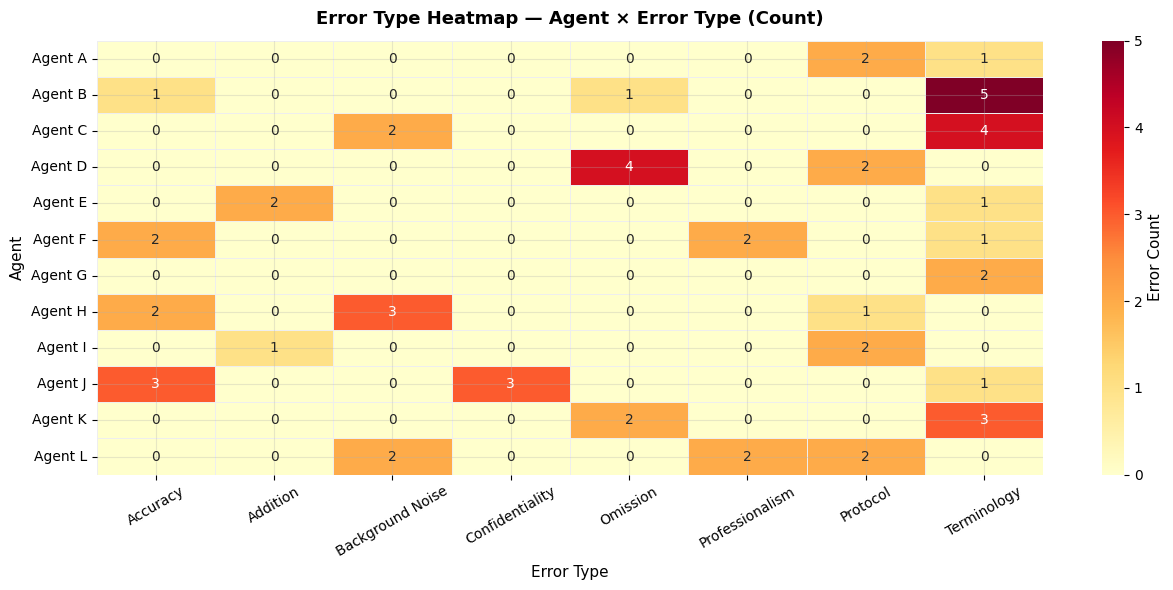

In [11]:
# Heatmap of Agent × Error Type (excluding 'No Error' and totals)
heat_cols = [c for c in pivot.columns if c not in ['No Error','TOTAL ERRORS']]
heat_data = pivot[heat_cols]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    heat_data,
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='#eeeeee',
    cbar_kws={'label': 'Error Count'},
    ax=ax
)
ax.set_title('Error Type Heatmap — Agent × Error Type (Count)', pad=12)
ax.set_xlabel('Error Type')
ax.set_ylabel('Agent')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Task 5: Error Severity Analysis <a id='5-severity'></a>

In [12]:
errors_only = df[df['Error Type'] != 'No Error'].copy()

sev_counts = errors_only['Error Severity'].value_counts().reindex(['Critical','Major','Minor'])
print('Error Severity Breakdown:')
for sev, cnt in sev_counts.items():
    print(f'  {sev:10s}: {cnt:3d}  ({cnt/len(errors_only):.1%})')

print('\nSeverity by Error Type:')
sev_pivot = (
    errors_only.groupby(['Error Type','Error Severity'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Critical','Major','Minor'])
)
sev_pivot['TOTAL'] = sev_pivot.sum(axis=1)
display(sev_pivot.sort_values('TOTAL', ascending=False))

Error Severity Breakdown:
  Critical  :  11  (18.6%)
  Major     :  28  (47.5%)
  Minor     :  20  (33.9%)

Severity by Error Type:


Error Severity,Critical,Major,Minor,TOTAL
Error Type,,,,
Terminology,3,5,10,18
Protocol,1,4,4,9
Accuracy,2,3,3,8
Background Noise,1,5,1,7
Omission,3,4,0,7
Professionalism,0,4,0,4
Confidentiality,1,2,0,3
Addition,0,1,2,3


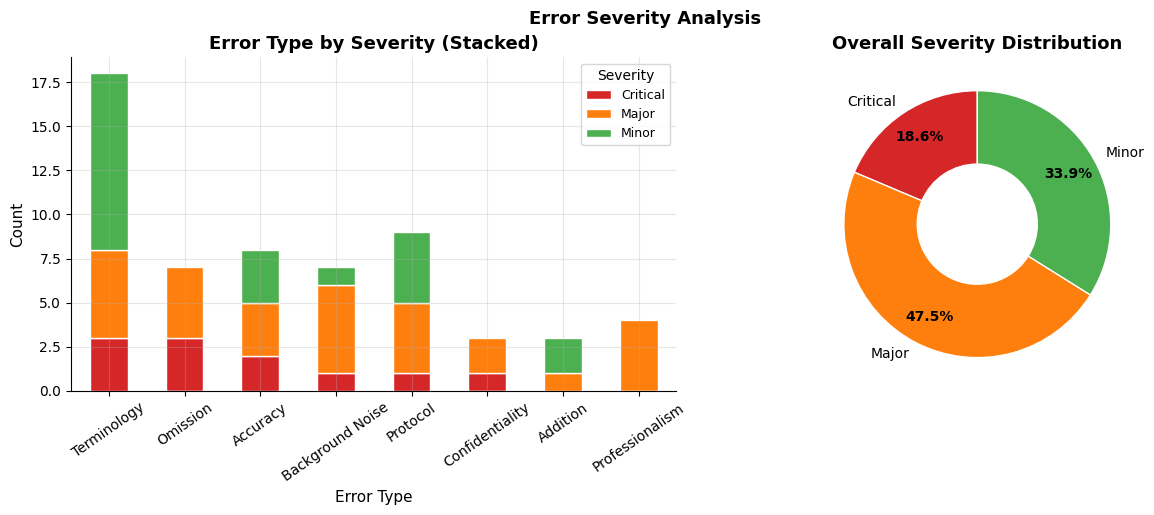

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar: Error Type × Severity
sev_plot = sev_pivot.drop(columns='TOTAL').sort_values('Critical', ascending=False)
sev_plot.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[RED, AMBER, '#4CAF50'], edgecolor='white'
)
axes[0].set_title('Error Type by Severity (Stacked)')
axes[0].set_xlabel('Error Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)
axes[0].legend(title='Severity', fontsize=9)

# Donut chart of severity distribution
sev_colors = [RED, AMBER, '#4CAF50']
wedges, texts, autotexts = axes[1].pie(
    sev_counts, labels=sev_counts.index, colors=sev_colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55, edgecolor='white')
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold')
axes[1].set_title('Overall Severity Distribution')

plt.tight_layout()
plt.suptitle('Error Severity Analysis', y=1.02, fontsize=13, fontweight='bold')
plt.show()

## 6. Task 6: Top 3 Error Types — Bar Chart <a id='6-chart'></a>

Top 3 Error Types:


,Error Type,Count,% of All Errors
0,Terminology,18,30.5%
1,Protocol,9,15.3%
2,Accuracy,8,13.6%


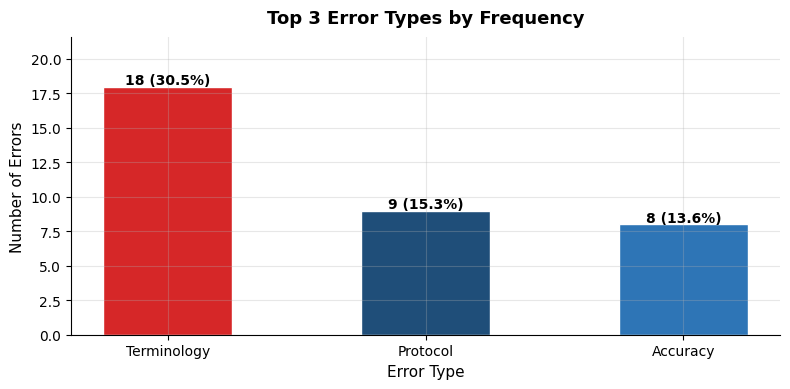


All Error Types Ranked:


,Error Type,Count,% of All Errors
0,Terminology,18,30.5%
1,Protocol,9,15.3%
2,Accuracy,8,13.6%
3,Omission,7,11.9%
4,Background Noise,7,11.9%
5,Professionalism,4,6.8%
6,Addition,3,5.1%
7,Confidentiality,3,5.1%


In [14]:
error_counts = (
    df[df['Error Type'] != 'No Error']['Error Type']
    .value_counts()
    .reset_index()
)
error_counts.columns = ['Error Type', 'Count']
error_counts['% of All Errors'] = error_counts['Count'] / error_counts['Count'].sum()

top3 = error_counts.head(3)
print('Top 3 Error Types:')
display(top3.assign(**{'% of All Errors': top3['% of All Errors'].map('{:.1%}'.format)}))

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [RED, NAVY, '#2E75B6']
bars = ax.bar(top3['Error Type'], top3['Count'],
              color=bar_colors, edgecolor='white', width=0.5)

for bar, (_, row) in zip(bars, top3.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{int(row['Count'])} ({row['% of All Errors']:.1%})",
            ha='center', fontweight='bold', fontsize=10)

ax.set_title('Top 3 Error Types by Frequency', pad=10)
ax.set_ylabel('Number of Errors')
ax.set_xlabel('Error Type')
ax.set_ylim(0, top3['Count'].max() * 1.2)
plt.tight_layout()
plt.show()

# Full ranking
print('\nAll Error Types Ranked:')
display(error_counts.assign(**{'% of All Errors': error_counts['% of All Errors'].map('{:.1%}'.format)}))

## 7. Task 7: Conditional Formatting Logic (Color-coded QA Scores) <a id='7-cf'></a>

In [15]:
# Excel equivalent:
#   =IF(G2<0.8, "CRITICAL", IF(G2<0.9, "AT RISK", "PASSING"))
# Conditional formatting rule:
#   <80%  → Red fill   (#FFE7E7) | Red bold text
#   80-90% → Amber fill (#FFF3CD) | Amber bold text
#   ≥90%  → Green fill (#E9F5E9) | Green text

def qa_status(score):
    if score < 0.80: return 'CRITICAL'
    elif score < 0.90: return 'AT RISK'
    else: return 'PASSING'

def row_color(score):
    if score < 0.80: return 'background-color: #FFE7E7; color: #C00000; font-weight: bold'
    elif score < 0.90: return 'background-color: #FFF3CD; color: #7F4F00; font-weight: bold'
    else: return 'background-color: #E9F5E9; color: #375623'

cf_table = df[['Agent Alias','Audit ID','Audit Date','QA Score','Critical Error',
               'Error Type','Error Severity','Missing Call']].copy()
cf_table['Status'] = cf_table['QA Score'].apply(qa_status)
cf_table['QA Score %'] = cf_table['QA Score'].map('{:.0%}'.format)

styled = (
    cf_table[['Agent Alias','Audit ID','Audit Date','QA Score %',
              'Critical Error','Error Type','Error Severity','Status']]
    .style
    .apply(lambda row: [row_color(float(row['QA Score %'].replace('%',''))/100)
                        if col == 'QA Score %' else '' for col in row.index], axis=1)
    .set_caption('QA Score Color-Coded by Threshold')
)
display(styled)

print('\nStatus Summary:')
print(cf_table['Status'].value_counts().to_string())

,Agent Alias,Audit ID,Audit Date,QA Score %,Critical Error,Error Type,Error Severity,Status
0,Agent A,QA-1001,2026-05-04 00:00:00,94%,No,No Error,nan,PASSING
1,Agent A,QA-1002,2026-05-05 00:00:00,95%,No,Terminology,Major,PASSING
2,Agent B,QA-1003,2026-05-05 00:00:00,72%,Yes,Accuracy,Critical,CRITICAL
3,Agent B,QA-1004,2026-05-07 00:00:00,71%,No,Omission,Major,CRITICAL
4,Agent C,QA-1005,2026-05-05 00:00:00,90%,No,Terminology,Minor,PASSING
5,Agent D,QA-1006,2026-05-06 00:00:00,68%,Yes,Omission,Critical,CRITICAL
6,Agent E,QA-1007,2026-05-04 00:00:00,94%,No,Addition,Minor,PASSING
7,Agent F,QA-1008,2026-05-08 00:00:00,77%,No,Professionalism,Major,CRITICAL
8,Agent G,QA-1009,2026-05-04 00:00:00,93%,No,Terminology,Minor,PASSING
9,Agent G,QA-1010,2026-05-04 00:00:00,90%,No,No Error,nan,PASSING



Status Summary:
Status
PASSING     34
AT RISK     24
CRITICAL    20


## 8. Task 8: Written Interpretation of Results <a id='8-interpretation'></a>

In [16]:
# Supporting statistics for the written interpretation
team_avg    = df['QA Score'].mean()
below_90    = (df['QA Score'] < 0.90).sum()
pct_below   = below_90 / len(df)
crit_count  = (df['Critical Error'] == 'Yes').sum()
missing_cnt = (df['Missing Call'] == 'Yes').sum()
top_error   = df[df['Error Type'] != 'No Error']['Error Type'].value_counts().idxmax()
worst_agent = summary.sort_values('Avg_QA').iloc[0]
best_agent  = summary.sort_values('Avg_QA').iloc[-1]

print(f'Team QA Average      : {team_avg:.1%}')
print(f'Audits below 90%     : {below_90} of {len(df)} ({pct_below:.1%})')
print(f'Critical Errors      : {crit_count}')
print(f'Missing Calls        : {missing_cnt}')
print(f'Most frequent error  : {top_error}')
print(f'Lowest avg QA agent  : {worst_agent["Agent Alias"]} ({worst_agent["Avg_QA"]:.1%})')
print(f'Highest avg QA agent : {best_agent["Agent Alias"]} ({best_agent["Avg_QA"]:.1%})')

Team QA Average      : 86.3%
Audits below 90%     : 44 of 78 (56.4%)
Critical Errors      : 11
Missing Calls        : 4
Most frequent error  : Terminology
Lowest avg QA agent  : Agent B (74.1%)
Highest avg QA agent : Agent I (95.0%)


### 📝 Written Interpretation

---

#### Overall Team Performance
The team of 12 agents produced **78 audited calls** across a 4-week review period. The **team average QA score is 86.3%**, which falls below the required **90% performance threshold**. Of the 78 individual audits, **44 (56%) scored below 90%** — indicating a team-wide quality gap that requires immediate and sustained intervention.

---

#### Top Issue — Terminology Errors (18 errors, 30.5% of all errors)
Terminology errors are the **single most frequent quality failure**, affecting **9 of 12 agents**. This is a team-wide pattern, not an individual anomaly, and points to a systemic gap in medical vocabulary training across specialties. This error type appears across Pharmacy, Pediatrics, and Lab Results call types.

---

#### Patient Safety Risk — Critical + Accuracy Errors
**11 Critical Errors** were recorded, concentrated in Agents B, D, and J (4, 4, and 2 respectively). Accuracy and Omission errors combined represent the highest patient safety risk — these indicate that **clinical meaning was changed during interpretation**, which can lead to wrong dosages, misunderstood diagnoses, or failure to follow discharge instructions.

---

#### Operational Risk — Missing Calls & Ring Time
**4 Missing Calls** were recorded across the period. Agent D accounts for the most concerning operational profile: lowest QA average (74.7%), highest ring time average, and multiple missing calls. From a client standpoint, missing calls constitute a potential **Title VI language access violation** and breach of the service agreement.

---

#### Positive Observations
**Agent I** is the strongest performer: 8 audits, **95.0% average QA**, 0 critical errors, and 2 perfect scores. **Agent A** also performs consistently (94.3% avg). These agents are candidates for **peer mentorship** during the team recovery period.

---

#### Recommended Priority Actions
| Priority | Agent / Scope | Action |
|----------|--------------|--------|
| 🔴 Immediate | Agent D | Formal PIP + supervisor shadowing + doubled audits |
| 🔴 Immediate | Agent B | Individual coaching: accuracy + terminology |
| 🟡 Short-term | All agents | Team-wide terminology refresher + bi-weekly quizzes |
| 🟡 Short-term | Agents C, D, H, L | Background noise / workspace compliance re-certification |
| 🟢 Monitor | Agent J | Confidentiality errors → HIPAA compliance review |

## 9. Bonus: Additional Deep-Dive Analyses <a id='9-bonus'></a>

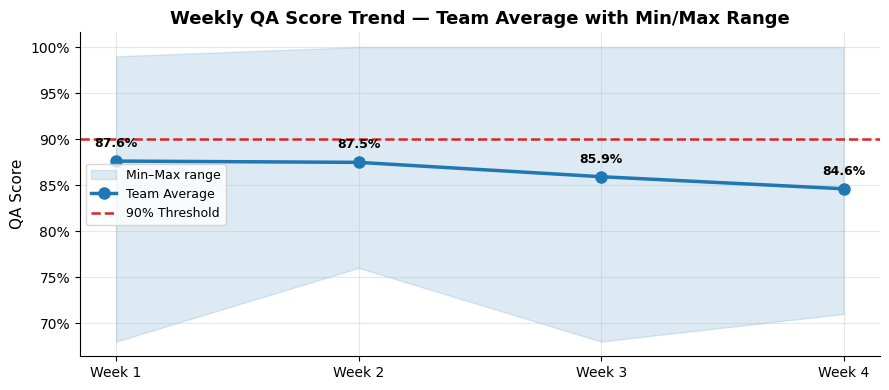

Weekly breakdown:


,mean,min,max
Week,,,
Week 1,87.6%,68.0%,99.0%
Week 2,87.5%,76.0%,100.0%
Week 3,85.9%,68.0%,100.0%
Week 4,84.6%,71.0%,100.0%


In [17]:
# ── Weekly QA Trend ────────────────────────────────────────────────────────
week_order = ['Week 1','Week 2','Week 3','Week 4']
weekly = df.groupby('Week')['QA Score'].agg(['mean','min','max']).reindex(week_order)

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(weekly.index, weekly['min'], weekly['max'],
                alpha=0.15, color=BLUE, label='Min–Max range')
ax.plot(weekly.index, weekly['mean'], marker='o', color=BLUE,
        linewidth=2.5, markersize=8, label='Team Average')
ax.axhline(THRESHOLD, color=RED, linestyle='--', linewidth=1.8, label='90% Threshold')

for i, (wk, row) in enumerate(weekly.iterrows()):
    ax.annotate(f"{row['mean']:.1%}", (i, row['mean']),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold')

ax.set_title('Weekly QA Score Trend — Team Average with Min/Max Range')
ax.set_ylabel('QA Score')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Weekly breakdown:')
display(weekly.map('{:.1%}'.format))

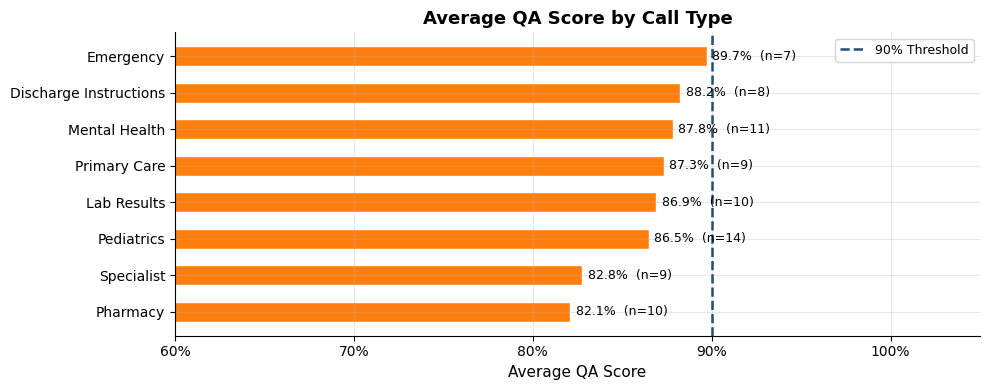

In [18]:
# ── QA Score by Call Type ──────────────────────────────────────────────────
ct = df.groupby('Call Type')['QA Score'].agg(['mean','count']).sort_values('mean')

fig, ax = plt.subplots(figsize=(10, 4))
bar_cols = [RED if v < 0.80 else (AMBER if v < 0.90 else GREEN) for v in ct['mean']]
bars = ax.barh(ct.index, ct['mean'], color=bar_cols, edgecolor='white', height=0.55)
ax.axvline(THRESHOLD, color=NAVY, linestyle='--', linewidth=1.8, label='90% Threshold')
ax.set_xlim(0.6, 1.05)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Average QA Score by Call Type')
ax.set_xlabel('Average QA Score')
for bar, (_, row) in zip(bars, ct.iterrows()):
    ax.text(row['mean'] + 0.003, bar.get_y() + bar.get_height()/2,
            f"{row['mean']:.1%}  (n={int(row['count'])})",
            va='center', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

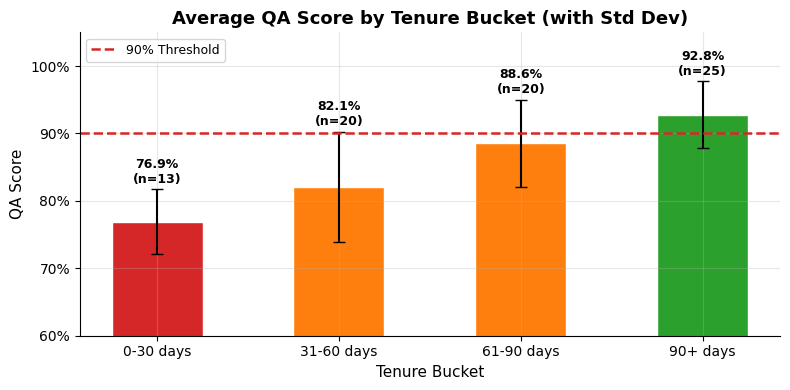

Tenure analysis:


,mean,count,std
Tenure Bucket,,,
0-30 days,76.9%,13,4.8%
31-60 days,82.1%,20,8.1%
61-90 days,88.6%,20,6.4%
90+ days,92.8%,25,5.0%


In [19]:
# ── QA Score by Tenure Bucket ──────────────────────────────────────────────
tenure_order = ['0-30 days','31-60 days','61-90 days','90+ days']
tenure = df.groupby('Tenure Bucket')['QA Score'].agg(['mean','count','std']).reindex(tenure_order)

fig, ax = plt.subplots(figsize=(8, 4))
t_colors = [RED if v < 0.80 else (AMBER if v < 0.90 else GREEN) for v in tenure['mean']]
ax.bar(tenure.index, tenure['mean'], color=t_colors,
       edgecolor='white', width=0.5,
       yerr=tenure['std'], capsize=4, error_kw={'color':'gray','linewidth':1.5})
ax.axhline(THRESHOLD, color=RED, linestyle='--', linewidth=1.8, label='90% Threshold')
ax.set_ylim(0.6, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Average QA Score by Tenure Bucket (with Std Dev)')
ax.set_ylabel('QA Score')
ax.set_xlabel('Tenure Bucket')
ax.legend(fontsize=9)
for i, (tb, row) in enumerate(tenure.iterrows()):
    ax.text(i, row['mean'] + row['std'] + 0.01,
            f"{row['mean']:.1%}\n(n={int(row['count'])})",
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print('Tenure analysis:')
display(tenure.map(lambda x: f'{x:.1%}' if isinstance(x, float) else x))

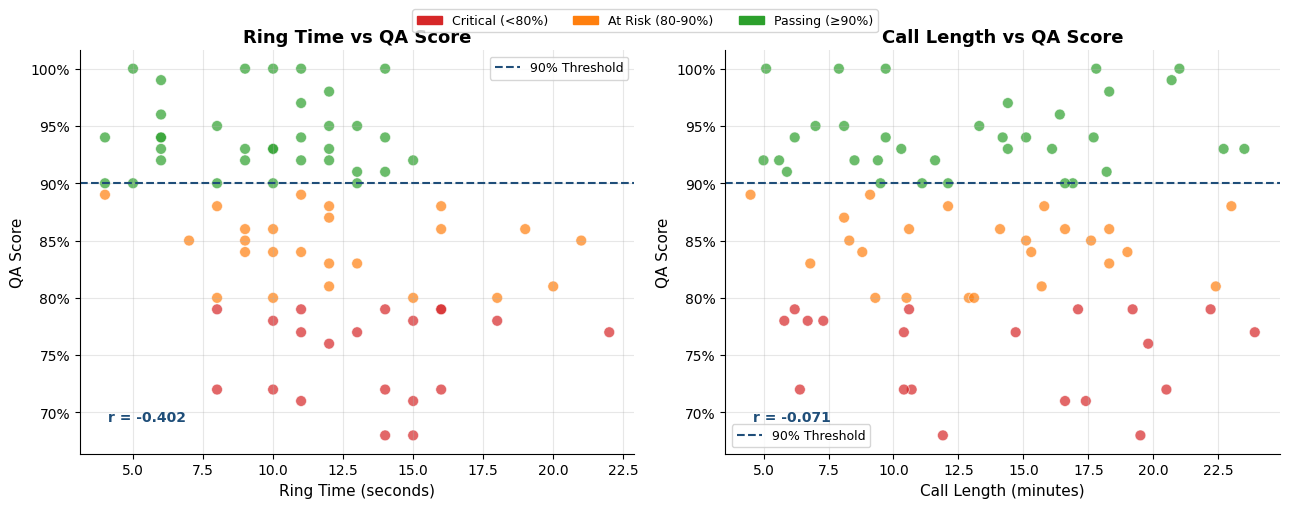

In [20]:
# ── Scatter: Ring Time vs QA Score ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ring Time vs QA Score
point_colors = [RED if s < 0.80 else (AMBER if s < 0.90 else GREEN) for s in df['QA Score']]
axes[0].scatter(df['Ring Time Sec'], df['QA Score'],
                c=point_colors, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
axes[0].axhline(THRESHOLD, color=NAVY, linestyle='--', linewidth=1.5, label='90% Threshold')
axes[0].set_title('Ring Time vs QA Score')
axes[0].set_xlabel('Ring Time (seconds)')
axes[0].set_ylabel('QA Score')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
corr1 = df['Ring Time Sec'].corr(df['QA Score'])
axes[0].text(0.05, 0.08, f'r = {corr1:.3f}', transform=axes[0].transAxes,
             fontsize=10, color=NAVY, fontweight='bold')
axes[0].legend(fontsize=9)

# Call Length vs QA Score
axes[1].scatter(df['Call Length Min'], df['QA Score'],
                c=point_colors, alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
axes[1].axhline(THRESHOLD, color=NAVY, linestyle='--', linewidth=1.5, label='90% Threshold')
axes[1].set_title('Call Length vs QA Score')
axes[1].set_xlabel('Call Length (minutes)')
axes[1].set_ylabel('QA Score')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
corr2 = df['Call Length Min'].corr(df['QA Score'])
axes[1].text(0.05, 0.08, f'r = {corr2:.3f}', transform=axes[1].transAxes,
             fontsize=10, color=NAVY, fontweight='bold')
axes[1].legend(fontsize=9)

patches = [mpatches.Patch(color=RED,label='Critical (<80%)'),
           mpatches.Patch(color=AMBER,label='At Risk (80-90%)'),
           mpatches.Patch(color=GREEN,label='Passing (≥90%)')]
fig.legend(handles=patches, loc='upper center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout()
plt.show()

Performance by Supervisor:


,Supervisor Alias,Agents,Audits,Avg_QA,Crit_Errs,Missing
0,Supervisor Alpha,4,26,84.7%,6,2
1,Supervisor Beta,4,25,85.8%,4,2
2,Supervisor Gamma,4,27,88.4%,1,0


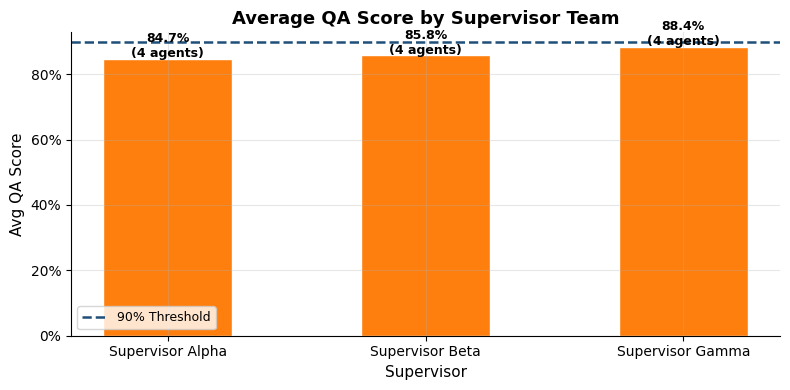

In [21]:
# ── Performance by Supervisor ──────────────────────────────────────────────
sup = df.groupby('Supervisor Alias').agg(
    Agents    = ('Agent Alias',   'nunique'),
    Audits    = ('Audit ID',      'count'),
    Avg_QA    = ('QA Score',      'mean'),
    Crit_Errs = ('Critical Error', lambda x: (x=='Yes').sum()),
    Missing   = ('Missing Call',   lambda x: (x=='Yes').sum()),
).reset_index()

print('Performance by Supervisor:')
disp_sup = sup.copy()
disp_sup['Avg_QA'] = disp_sup['Avg_QA'].map('{:.1%}'.format)
display(disp_sup)

fig, ax = plt.subplots(figsize=(8, 4))
sup_colors = [RED if v < 0.80 else (AMBER if v < 0.90 else GREEN) for v in sup['Avg_QA']]
ax.bar(sup['Supervisor Alias'], sup['Avg_QA'], color=sup_colors, edgecolor='white', width=0.5)
ax.axhline(THRESHOLD, color=NAVY, linestyle='--', linewidth=1.8, label='90% Threshold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_title('Average QA Score by Supervisor Team')
ax.set_ylabel('Avg QA Score'); ax.set_xlabel('Supervisor')
for i, (_, row) in enumerate(sup.iterrows()):
    ax.text(i, row['Avg_QA'] + 0.005, f"{row['Avg_QA']:.1%}\n({row['Agents']} agents)",
            ha='center', fontsize=9, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
### 📌 Formula Reference

| Python (pandas) | Excel Equivalent | Purpose |
|---|---|---|
| `groupby('Agent Alias')['QA Score'].mean()` | `=AVERAGEIF(B:B, agent, G:G)` | Avg QA per agent |
| `groupby('Agent Alias').size()` | `=COUNTIF(B:B, agent)` | Audit count per agent |
| `(x == 'Yes').sum()` (inside groupby) | `=COUNTIFS(B:B, agent, H:H, "Yes")` | Critical errors per agent |
| `s < 0.9` boolean mask | `=IF(D6<0.9,"Yes","No")` | Below-90% flag |
| `groupby().min() / .max()` | `=MINIFS(G:G,B:B,agent)` / `=MAXIFS(...)` | Min/Max QA per agent |
| `pd.crosstab() / .unstack()` | PivotTable: Rows=Agent, Cols=Error Type | Error pivot |
| `apply(lambda: color)` on style | Conditional Formatting rules | Color-coded QA scores |
| `df['QA Score'].corr(df['Ring Time Sec'])` | `=CORREL(G:G, N:N)` | Correlation Ring Time ↔ QA |

---
*QA Dataset Analysis — Medical Interpretation Team*